# pzflow learned noise models

In this notebook we show how we can use the [pzflow package](https://jfcrenshaw.github.io/pzflow/) to  sample bandflux errors (uncertainties) from a photometric catalog. The pzflow model, as well as the input catalog data, are assumed to provide the standard deviation of the bandflux, while the noise itself is assumed to be Gaussian. The pzflow model samples bandflux errors conditionally to bandflux, passband and other relevant parameters from the `ObsTable`.

Note that the [pzflow package](https://jfcrenshaw.github.io/pzflow/) is not installed as part of the default LightCurveLynx installation. Users will need to manually install pzflow via pip (e.g. `pip install pzflow`) in order to run this notebook.

In [1]:
import numpy as np
import pandas as pd

from lightcurvelynx.noise_models.pzflow_noise_model import learn_pzflow_noise_model

## Training the PZFlow model

We start by generating a fake observational data set consisting of zero point and readout noise information.

In [2]:
num_training_samples = 10_000

# The input parameters for the pzflow model will be bandflux, zp, and readout_noise.
bandflux = np.random.normal(loc=500.0, scale=100.0, size=num_training_samples)
zp = np.random.normal(loc=10.0, scale=0.15, size=num_training_samples)
readout_noise = np.random.normal(loc=5.0, scale=1.0, size=num_training_samples)

source_variance = bandflux / zp
readout_variance = readout_noise**2  # Assume 1 exposure and psf_footprint = 1.

# This is the value the pzflow model is trained to predict.
flux_err = np.sqrt(source_variance + readout_variance) * zp

We can train a pzflow-based noise model from this toy distribution by: 1) putting the data into single data frame and 2) using the ``learn_pzflow_noise_model`` function.

In [ ]:
training_data = pd.DataFrame(
    {
        "bandflux": bandflux,
        "zp": zp,
        "readout_noise": readout_noise,
        "flux_err": flux_err,
    }
)
noise_model = learn_pzflow_noise_model(training_data, noise_column="flux_err", normalize=True)

# We can save the flow to an output file (which is how we generated the flow used in the tests).
# from lightcurvelynx import _LIGHTCURVELYNX_TEST_DATA_DIR
# noise_model.save_to_file(_LIGHTCURVELYNX_TEST_DATA_DIR / "fake_noise_flow.pkl")

The `noise_model` object is now a trained noise model with a trained pzflow model and normalization metadata.

## Applying the noise model

The learned noise model's `apply_noise` function first uses the pzflow to sample the flur errors (standard deviation of the noise for each observation). Then it uses those sampled flux errors to add noise to the bandfluxes. Both the new bandfluxes and the errors are returned.

In order to query `apply_noise`, we need to provide it with the same information it will have during the simulation. Namely a `ObsTable` with the relevant survey information and a `bandflux` array with the simulated noise-free bandfluxes. We start by defining the `ObsTable` with the relevant information. Only the `zp` column and the `read_noise` constant are needed for the noise computation, but we need a few other columns (`time`, `ra`, `dec`) for the `OpSim` class itself.

In [4]:
from lightcurvelynx.obstable.opsim import OpSim

data = pd.DataFrame(
    {
        "time": 60676.0 + np.arange(100),
        "ra": np.random.uniform(0, 360, size=100),
        "dec": np.random.uniform(-90, 90, size=100),
        "zp": np.random.normal(loc=10.0, scale=0.15, size=100),
    }
)
obs_table = OpSim(data, read_noise=4.5)

# Use a linear arrangement of bandfluxes
bandflux = np.linspace(400.0, 600.0, 100)

If you look closely at the `OpSim` and `training_data` declarations above, you can see that they use different names for one of the columns. The training data uses a column called `readout_noise` while the `OpSim` uses `read_noise`. In general we expect this to happen when a single noise model is trained and applied on slightly different sets of observations. The `PZFlowNoiseModel` provides a helper function that performs these mappings automatically so you do not need to change either the model or the survey information.

In [5]:
noise_model.add_column_mapping("readout_noise", "read_noise")

Now we can apply the model to our fake bandfluxes.

In [6]:
indices = np.arange(100)
noisy_flux, flux_err = noise_model.apply_noise(bandflux, obs_table=obs_table, indices=indices)

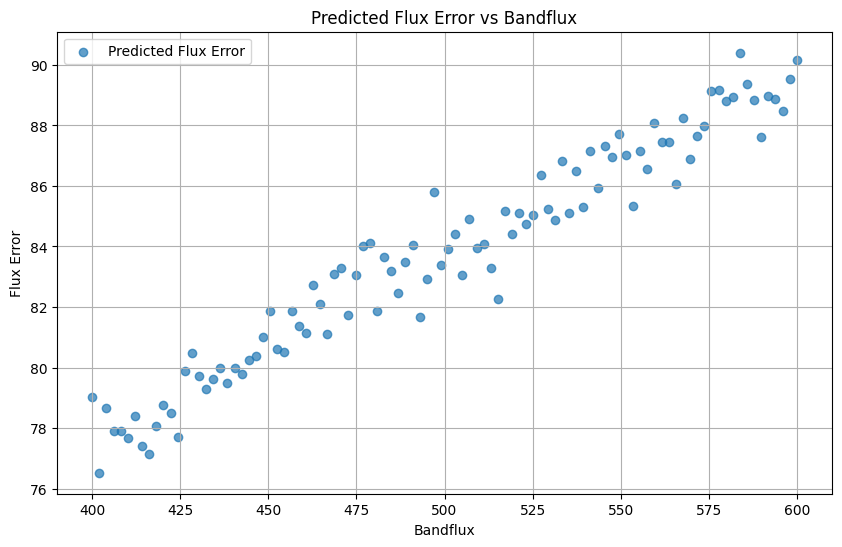

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(bandflux, flux_err, label="Predicted Flux Error", alpha=0.7)
plt.xlabel("Bandflux")
plt.ylabel("Flux Error")
plt.title("Predicted Flux Error vs Bandflux")
plt.legend()
plt.grid()
plt.show()

## Conclusion

The `PZFlowNoiseModel` object can be used like any other noise model during simulation.